In [11]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

history_dir = Path("../output/analytics_logs")
history_files = sorted(history_dir.glob("run_*.json"))

if not history_files:
    raise FileNotFoundError(f"No analytics history files found in {history_dir}")

run_rows = []
for path in history_files:
    data = json.loads(path.read_text(encoding="utf-8"))
    summary = dict(data["summary"] )
    summary["history_file"] = path.name
    run_rows.append(summary)

run_history = pd.DataFrame(run_rows).sort_values("generated_at").reset_index(drop=True)
latest_data = json.loads(history_files[-1].read_text(encoding="utf-8"))
latest_tasks = pd.DataFrame(latest_data["tasks"])
latest_run = run_history.iloc[-1]
previous_run = run_history.iloc[-2] if len(run_history) > 1 else None

run_history

,run_id,generated_at,tasks,pipeline_elapsed_seconds,router_prompt_tokens,router_completion_tokens,router_total_tokens,prompt_tokens,completion_tokens,total_tokens,average_model_elapsed_seconds,history_file
0,4a008ab4716a42edab0cd62baf490047,2026-07-08T02:38:08.123875+00:00,8,26.1418,NaN,NaN,NaN,1756,962,2718,1.5080,run_4a008ab4716a42edab0cd62baf490047.json
1,3a0cb60c01b8488a80db9c74cbd6946d,2026-07-08T02:50:15.450128+00:00,8,31.1775,NaN,NaN,NaN,554,961,1515,1.8317,run_3a0cb60c01b8488a80db9c74cbd6946d.json
2,c88580046e7d4e61a0ed57760ad11ceb,2026-07-08T02:59:04.335974+00:00,8,8.7613,NaN,NaN,NaN,1506,857,2363,1.5589,run_c88580046e7d4e61a0ed57760ad11ceb.json
3,8beb3d44b72d43a9a9e586229c9d6b46,2026-07-08T03:27:07.275028+00:00,8,7.0535,4332.0,880.0,5212.0,1506,805,2311,2.3051,run_8beb3d44b72d43a9a9e586229c9d6b46.json
4,49ffa64f8ef54aa88db5697bb9104190,2026-07-08T03:29:43.156341+00:00,8,5.3215,4332.0,632.0,4964.0,1506,798,2304,1.9224,run_49ffa64f8ef54aa88db5697bb9104190.json
5,068b6f27043c4f90a7d48ad4d16a74e9,2026-07-08T03:31:38.165929+00:00,8,7.3251,4332.0,874.0,5206.0,1506,798,2304,2.2076,run_068b6f27043c4f90a7d48ad4d16a74e9.json
6,d78e6dd18ebe4b3b995bee2ab4586b17,2026-07-08T03:36:56.010127+00:00,8,10.9770,4332.0,752.0,5084.0,1387,821,2208,2.9343,run_d78e6dd18ebe4b3b995bee2ab4586b17.json
7,dda75617fd734c059cd7c8404867871a,2026-07-08T03:38:40.988715+00:00,8,12.0696,4332.0,778.0,5110.0,1506,763,2269,3.8628,run_dda75617fd734c059cd7c8404867871a.json
8,95ed2fae21ab419587fa38be612cfc5f,2026-07-08T04:23:42.799731+00:00,8,7.8814,4332.0,896.0,5228.0,1506,845,2351,1.1682,run_95ed2fae21ab419587fa38be612cfc5f.json
9,3027dd2e39de4746a93259251d510f1e,2026-07-08T04:23:55.054133+00:00,8,4.0371,4332.0,793.0,5125.0,1506,895,2401,1.2322,run_3027dd2e39de4746a93259251d510f1e.json


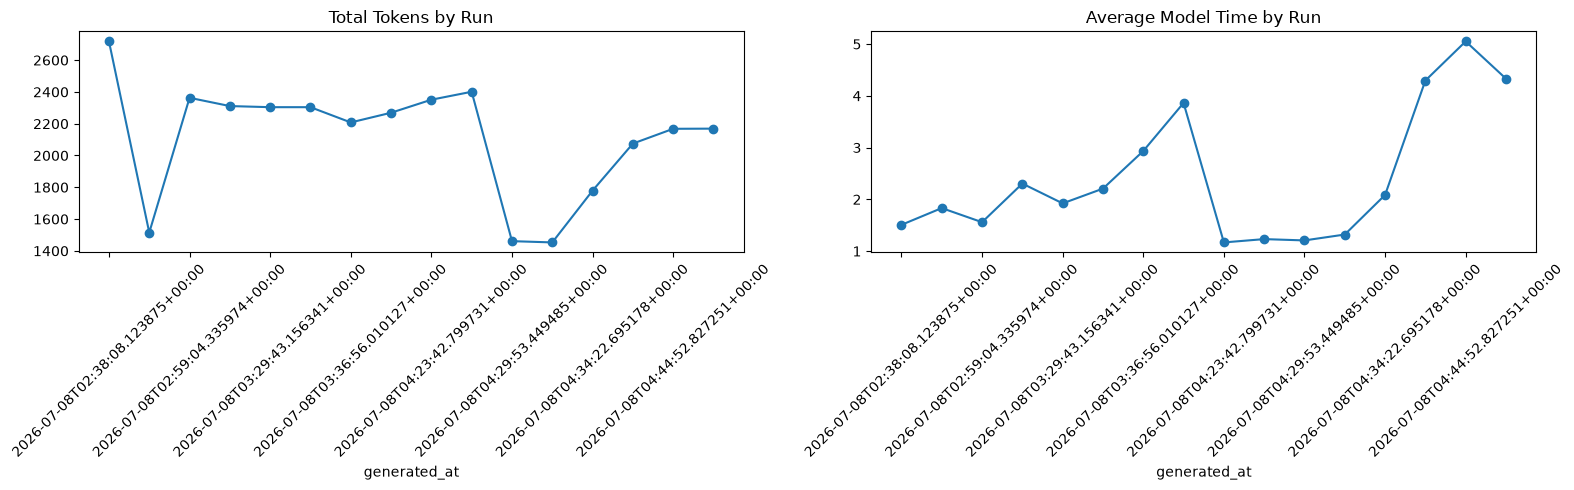

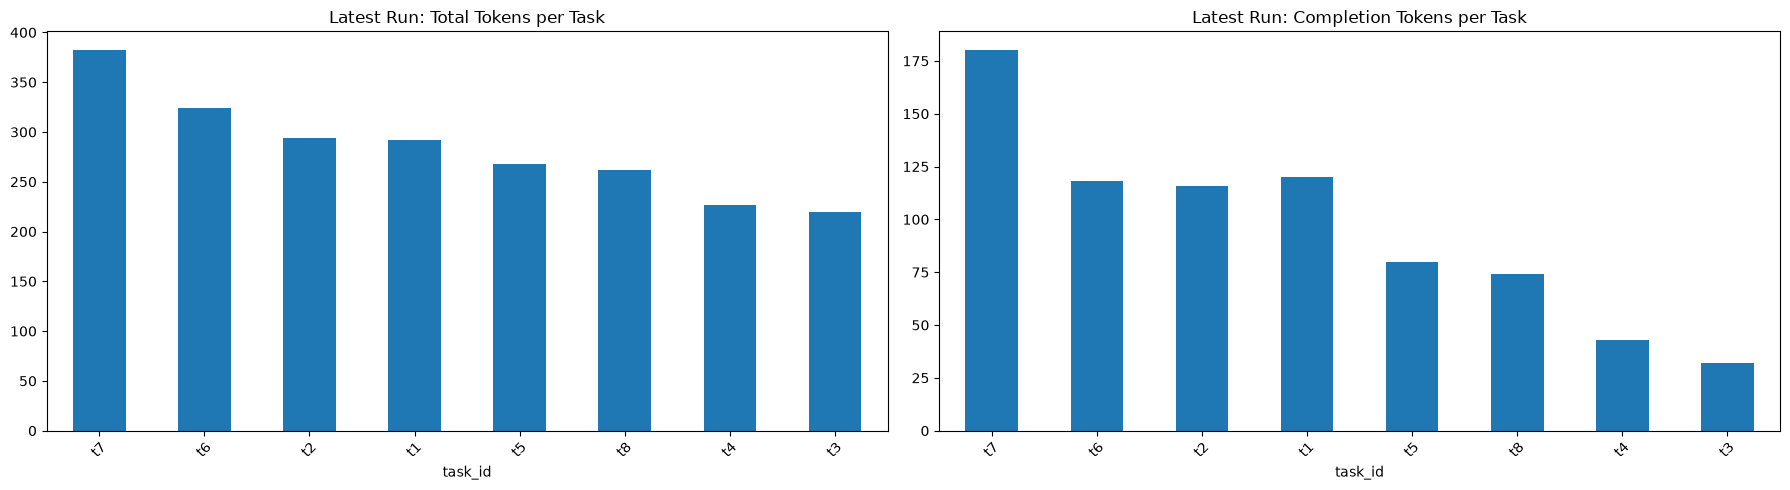

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

run_history.plot(x="generated_at", y="total_tokens", ax=axes[0], marker="o", legend=False, title="Total Tokens by Run")
run_history.plot(x="generated_at", y="average_model_elapsed_seconds", ax=axes[1], marker="o", legend=False, title="Average Model Time by Run")

for axis in axes:
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

latest_tasks.sort_values("total_tokens", ascending=False).plot.bar(
    x="task_id",
    y="total_tokens",
    ax=axes[0],
    legend=False,
    title="Latest Run: Total Tokens per Task",
)

latest_tasks.sort_values("total_tokens", ascending=False).plot.bar(
    x="task_id",
    y="completion_tokens",
    ax=axes[1],
    legend=False,
    title="Latest Run: Completion Tokens per Task",
)

for axis in axes:
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Latest run:


,latest
tasks,8
total_tokens,2169
prompt_tokens,1268
completion_tokens,901
pipeline_elapsed_seconds,12.2473
average_model_elapsed_seconds,4.3312
generated_at,2026-07-08T04:46:48.317296+00:00
history_file,run_70cac96ee9ae4fb4b4f2fe4d948ff647.json
run_id,70cac96ee9ae4fb4b4f2fe4d948ff647


Previous run:


,previous
tasks,8
total_tokens,2168
prompt_tokens,1268
completion_tokens,900
pipeline_elapsed_seconds,15.6752
average_model_elapsed_seconds,5.0523
generated_at,2026-07-08T04:44:52.827251+00:00
history_file,run_c8f22623cf2541499b285699b733509f.json
run_id,c8f22623cf2541499b285699b733509f


Run comparison:


,latest,previous,delta
total_tokens,2169,2168,1
prompt_tokens,1268,1268,0
completion_tokens,901,900,1
pipeline_elapsed_seconds,12.2473,15.6752,-3.4279
average_model_elapsed_seconds,4.3312,5.0523,-0.7211


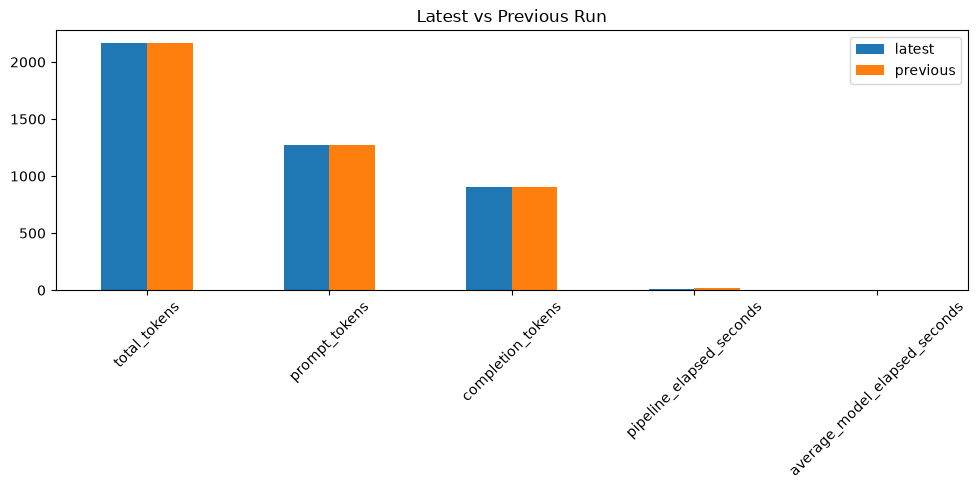

Latest task breakdown:


,task_id,category,confidence,method,router_model,router_prompt_tokens,router_completion_tokens,router_total_tokens,chosen_model,reason,prompt_template,max_tokens,model_elapsed_seconds,prompt_tokens,completion_tokens,total_tokens
6,t7,logical_deductive_reasoning,0.97,ai_router,accounts/fireworks/models/minimax-m3,555,166,721,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,Solve the puzzle with concise reasoning and th...,180,1.7815,202,180,382
5,t6,code_debugging,0.99,ai_router,accounts/fireworks/models/minimax-m3,557,97,654,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,Identify the bug and provide a corrected versi...,220,2.4818,206,118,324
1,t2,mathematical_reasoning,0.99,ai_router,accounts/fireworks/models/minimax-m3,532,69,601,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,Show only the necessary steps and the final an...,180,2.2561,178,116,294
0,t1,factual_knowledge,0.95,ai_router,accounts/fireworks/models/minimax-m3,528,54,582,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,Answer briefly and clearly in plain English.,120,8.6721,172,120,292
4,t5,named_entity_recognition,0.99,ai_router,accounts/fireworks/models/minimax-m3,540,59,599,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,"Extract people, organizations, and locations a...",96,2.0861,188,80,268
7,t8,code_generation,0.99,ai_router,accounts/fireworks/models/minimax-m3,541,101,642,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,Write the function or code solution directly w...,240,1.6106,188,74,262
3,t4,text_summarisation,0.97,ai_router,accounts/fireworks/models/minimax-m3,539,71,610,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,Summarise the passage in one sentence.,120,9.8895,184,43,227
2,t3,sentiment_classification,0.92,ai_router,accounts/fireworks/models/minimax-m3,540,161,701,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,"Return only one label: Positive, Negative, or ...",32,2.1251,188,32,220


In [14]:
compare_cols = [
    "tasks",
    "total_tokens",
    "prompt_tokens",
    "completion_tokens",
    "pipeline_elapsed_seconds",
    "average_model_elapsed_seconds",
    "generated_at",
    "history_file",
    "run_id",
]

print("Latest run:")
display(latest_run[compare_cols].to_frame(name="latest"))

if previous_run is not None:
    print("Previous run:")
    display(previous_run[compare_cols].to_frame(name="previous"))

    comparison = pd.DataFrame({
        "latest": latest_run[["total_tokens", "prompt_tokens", "completion_tokens", "pipeline_elapsed_seconds", "average_model_elapsed_seconds"]],
        "previous": previous_run[["total_tokens", "prompt_tokens", "completion_tokens", "pipeline_elapsed_seconds", "average_model_elapsed_seconds"]],
    })
    comparison["delta"] = comparison["latest"] - comparison["previous"]
    print("Run comparison:")
    display(comparison)

    fig, ax = plt.subplots(figsize=(10, 5))
    comparison[["latest", "previous"]].plot.bar(ax=ax, title="Latest vs Previous Run")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Only one run is available, so there is no previous run to compare.")

print("Latest task breakdown:")
display(latest_tasks.sort_values("total_tokens", ascending=False))